# 3. From polarisations to an LVK detector network

**FQCP 2026 · Bayesian parameter estimation for gravitational-wave sources**

> Designed for Google Colab. Run top to bottom; **Extension** sections may be skipped live.


## Response and localisation

\[
\tilde h_I(f)=[F^I_+\tilde h_+(f)+F^I_\times\tilde h_\times(f)]e^{-2\pi if\Delta t_I}.
\]

Sky position is shared, but each site has different antenna factors, arrival delay, PSD, and calibration. The coherent network log likelihood sums detector contributions.

In [1]:
import os, sys, subprocess, importlib.util
IN_COLAB = "COLAB_RELEASE_TAG" in os.environ
if importlib.util.find_spec("bilby") is None:
    if IN_COLAB: subprocess.check_call([sys.executable,"-m","pip","install","-q","bilby==2.8.0"])
    else: raise ImportError("Install bilby==2.8.0, or run in Colab.")

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ
rng = np.random.default_rng(20260817)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["animation.html"] = "jshtml"
print("Running in Colab:", IN_COLAB)

Running in Colab: False


In [3]:
import bilby
gps_time=1126259462.4; ra_true,dec_true,psi_true=1.2,-.4,.7
ifos=bilby.gw.detector.InterferometerList(["H1","L1","V1"])
print("Detector   F+       Fx      geocentre delay [ms]")
for ifo in ifos:
    fp=ifo.antenna_response(ra_true,dec_true,gps_time,psi_true,"plus")
    fx=ifo.antenna_response(ra_true,dec_true,gps_time,psi_true,"cross")
    dt=ifo.time_delay_from_geocenter(ra_true,dec_true,gps_time)
    print(f"{ifo.name:>5s}   {fp:+.3f}   {fx:+.3f}       {1e3*dt:+.2f}")

Detector   F+       Fx      geocentre delay [ms]
   H1   +0.366   +0.334       -3.18
   L1   -0.263   -0.597       -11.80
   V1   +0.108   -0.159       +3.83


Changing $\psi$ rotates the plus/cross sky basis; it does not move the source. Differently oriented detectors help resolve the two components.

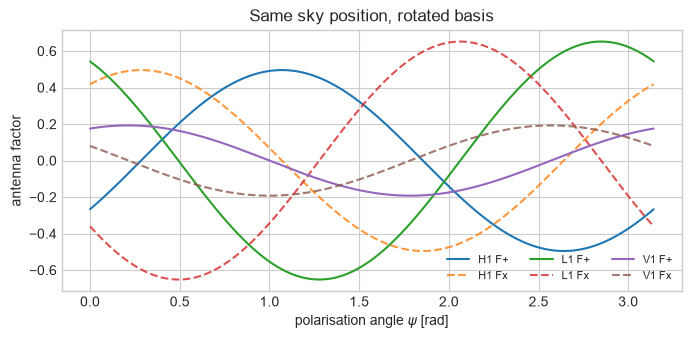

In [4]:
psi=np.linspace(0,np.pi,240); fig,ax=plt.subplots(figsize=(8,3.4))
for ifo in ifos:
    fp=[ifo.antenna_response(ra_true,dec_true,gps_time,p,"plus") for p in psi]
    fx=[ifo.antenna_response(ra_true,dec_true,gps_time,p,"cross") for p in psi]
    ax.plot(psi,fp,label=f"{ifo.name} F+"); ax.plot(psi,fx,"--",alpha=.8,label=f"{ifo.name} Fx")
ax.set(xlabel=r"polarisation angle $\psi$ [rad]",ylabel="antenna factor",title="Same sky position, rotated basis"); ax.legend(ncol=3,fontsize=8); plt.show()

## Timing-only localisation

Two sites constrain a delay ring; a third reduces it. A real posterior also uses coherent phase, amplitudes, polarisation, waveform uncertainty, Earth rotation, and priors.

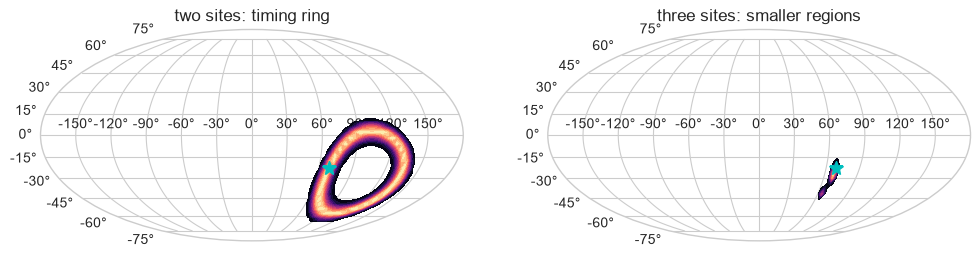

In [5]:
ra=np.linspace(-np.pi,np.pi,91); dec=np.linspace(-np.pi/2,np.pi/2,46); RA,DEC=np.meshgrid(ra,dec)
delays={ifo.name:np.array([[ifo.time_delay_from_geocenter(r,d,gps_time) for r in ra] for d in dec]) for ifo in ifos}
obs={ifo.name:ifo.time_delay_from_geocenter(ra_true,dec_true,gps_time) for ifo in ifos}; sigma_t=3e-4
def timing_ll(names):
    ref=names[0]; value=np.zeros_like(RA)
    for name in names[1:]: value-=.5*((delays[name]-delays[ref]-(obs[name]-obs[ref]))/sigma_t)**2
    return value
fig,axes=plt.subplots(1,2,figsize=(12,4),subplot_kw={"projection":"mollweide"})
for ax,names,title in zip(axes,[["H1","L1"],["H1","L1","V1"]],["two sites: timing ring","three sites: smaller regions"]):
    ll=timing_ll(names); density=np.exp(ll-ll.max()); ax.contourf(RA,DEC,density,levels=np.linspace(.05,1,15),cmap="magma")
    ax.plot(ra_true,dec_true,"c*",ms=10); ax.set_title(title); ax.grid(True)
plt.show()

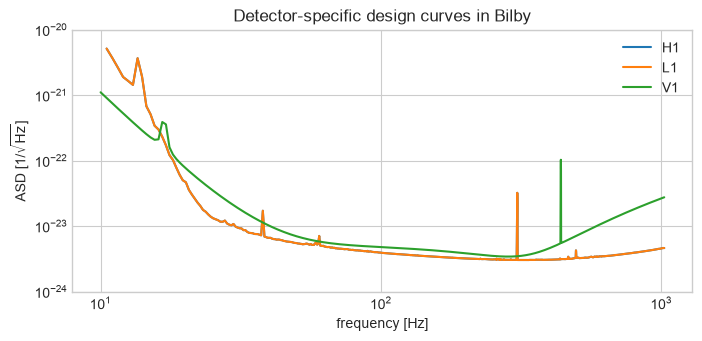

In [6]:
fig,ax=plt.subplots(figsize=(8,3.4)); f=np.linspace(10,1024,2000)
for ifo in ifos: ax.loglog(f,ifo.power_spectral_density.get_amplitude_spectral_density_array(f),label=ifo.name)
ax.set(xlabel="frequency [Hz]",ylabel=r"ASD [1/$\sqrt{\mathrm{Hz}}$]",title="Detector-specific design curves in Bilby",ylim=(1e-24,1e-20)); ax.legend(); plt.show()

## “Yay Bilby”: project both polarisations in one call

The narrow-band polarisations below stand in for rippleGW output. `get_detector_response` applies antenna factors and timing. A CBC likelihood invokes this machinery repeatedly.

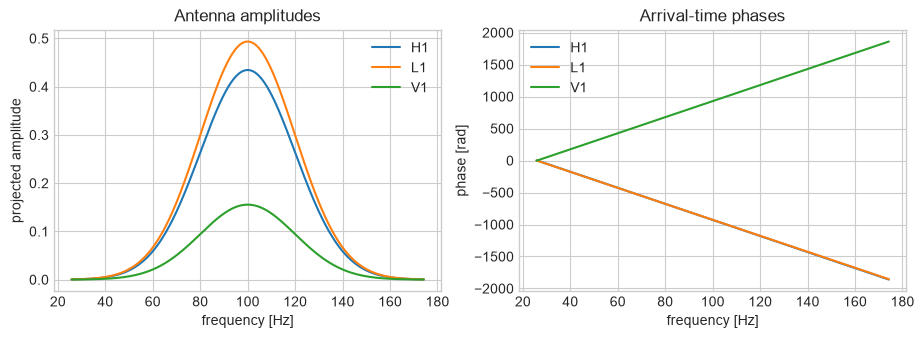

In [7]:
for ifo in ifos: ifo.set_strain_data_from_zero_noise(sampling_frequency=1024,duration=4,start_time=gps_time-2)
f=ifos[0].frequency_array; hp=np.exp(-.5*((f-100)/20)**2).astype(complex); hx=-.7j*hp
parameters=dict(ra=ra_true,dec=dec_true,psi=psi_true,geocent_time=gps_time)
fig,(aa,ap)=plt.subplots(1,2,figsize=(11,3.4))
for ifo in ifos:
    h=ifo.get_detector_response({"plus":hp,"cross":hx},parameters,frequencies=f); keep=np.abs(hp)>1e-3
    aa.plot(f[keep],np.abs(h[keep]),label=ifo.name); ap.plot(f[keep],np.unwrap(np.angle(h[keep])),label=ifo.name)
aa.set(xlabel="frequency [Hz]",ylabel="projected amplitude",title="Antenna amplitudes")
ap.set(xlabel="frequency [Hz]",ylabel="phase [rad]",title="Arrival-time phases"); aa.legend(); ap.legend(); plt.show()

In [8]:
print("""waveform_generator = bilby.gw.WaveformGenerator(...)
likelihood = bilby.gw.likelihood.GravitationalWaveTransient(
    interferometers=ifos, waveform_generator=waveform_generator)
result = bilby.run_sampler(likelihood, priors, ...)

Bilby handles the response and coherent likelihood for us. Yay Bilby!""")

waveform_generator = bilby.gw.WaveformGenerator(...)
likelihood = bilby.gw.likelihood.GravitationalWaveTransient(
    interferometers=ifos, waveform_generator=waveform_generator)
result = bilby.run_sampler(likelihood, priors, ...)

Bilby handles the response and coherent likelihood for us. Yay Bilby!


## Boundary

The map is timing-only, and the PSDs are design curves rather than event estimates. Production work samples nuisance parameters and tests waveform, PSD, and calibration choices.

- [Bilby detector API](https://bilby-dev.github.io/bilby/api/bilby.gw.detector.interferometer.Interferometer.html)
- [Bilby CBC tutorial](https://bilby-dev.github.io/bilby/compact-binary-coalescence-parameter-estimation.html)